In [1]:
import tensorflow as tf

# Check for available physical GPUs
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))
print("GPU Devices: ", gpus)

# Check if TensorFlow is currently executing on a GPU
print("Built with CUDA:", tf.test.is_built_with_cuda())

2026-06-14 16:41:40.364368: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-14 16:41:40.510446: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-14 16:41:40.530248: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-14 16:41:40.980495: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: li

Num GPUs Available:  1
GPU Devices:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True


2026-06-14 16:41:41.606886: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-06-14 16:41:41.634805: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-06-14 16:41:41.637249: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [2]:
import tensorflow as tf
import numpy as np
import os
import ast
import logging
import string
import random
import yaml
from datetime import datetime

from dimenet.model.dimenet import DimeNet
from dimenet.model.dimenet_pp import DimeNetPP
from dimenet.model.activations import swish
from dimenet.training.trainer import Trainer
from dimenet.training.metrics import Metrics
"""from dimenet.training.data_container import DataContainer
from dimenet.training.data_provider import DataProvider"""
# custom dataloader
from custom.data_container import DataContainer
from custom.data_provider import DataProvider

/home/n7student/Documents/2A/S2/contraintes/projet_kaggle/dimenet/.venv/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# Set up logger
logger = logging.getLogger()
logger.handlers = []
ch = logging.StreamHandler()
formatter = logging.Formatter(
        fmt='%(asctime)s (%(levelname)s): %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S')
ch.setFormatter(formatter)
logger.addHandler(ch)
logger.setLevel('INFO')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'
tf.get_logger().setLevel('WARN')
tf.autograph.set_verbosity(2)

### Load config

In [5]:
# config.yaml for DimeNet, config_pp.yaml for DimeNet++
use_pretrained = True
pp = True

if use_pretrained:
    if pp == True:
        config_file = 'config_pp.yaml'
    else:
        config_file = 'config.yaml'
else:
    config_file = 'custom_config.yaml'



with open(config_file, 'r') as c:
    config = yaml.safe_load(c)

In [6]:
# For strings that yaml doesn't parse (e.g. None)
for key, val in config.items():
    if type(val) is str:
        try:
            config[key] = ast.literal_eval(val)
        except (ValueError, SyntaxError):
            pass

In [7]:
model_name = config['model_name']

if model_name == "dimenet":
    num_bilinear = config['num_bilinear']
elif model_name == "dimenet++":
    out_emb_size = config['out_emb_size']
    int_emb_size = config['int_emb_size']
    basis_emb_size = config['basis_emb_size']
    extensive = config['extensive']
else:
    raise ValueError(f"Unknown model name: '{model_name}'")
    
emb_size = config['emb_size']
num_blocks = config['num_blocks']

num_spherical = config['num_spherical']
num_radial = config['num_radial']
output_init = config['output_init']

cutoff = config['cutoff']
envelope_exponent = config['envelope_exponent']

num_before_skip = config['num_before_skip']
num_after_skip = config['num_after_skip']
num_dense_output = config['num_dense_output']

num_train = config['num_train']
#num_valid = config['num_valid']
data_seed = config['data_seed']
#dataset = config['dataset']
logdir = config['logdir']

num_steps = config['num_steps']
ema_decay = config['ema_decay']

learning_rate = config['learning_rate']
warmup_steps = config['warmup_steps']
decay_rate = config['decay_rate']
decay_steps = config['decay_steps']

batch_size = config['batch_size']
evaluation_interval = config['evaluation_interval']
save_interval = config['save_interval']
restart = config['restart']
comment = config['comment']
#targets = config['targets']

### Create directories

In [8]:
# Used for creating a random "unique" id for this run
def id_generator(size=8, chars=string.ascii_uppercase + string.ascii_lowercase + string.digits):
    return ''.join(random.SystemRandom().choice(chars) for _ in range(size))

# Create directories
# A unique directory name is created for this run based on the input
if restart is None:
    directory = (logdir + "/" + datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + id_generator() + "_" + comment)
else:
    directory = restart
logging.info(f"Directory: {directory}")

if not os.path.exists(directory):
    os.makedirs(directory)
best_dir = os.path.join(directory, 'best')
if not os.path.exists(best_dir):
    os.makedirs(best_dir)
log_dir = os.path.join(directory, 'logs')
if not os.path.exists(log_dir):
    os.makedirs(log_dir)
best_loss_file = os.path.join(best_dir, 'best_loss.npz')
best_ckpt_file = os.path.join(best_dir, 'ckpt')
step_ckpt_folder = log_dir

2026-06-14 16:41:42 (INFO): Directory: ./20260614_164142_NzVBe2K1_ppPHYv2


### Create summary writer and metrics

In [9]:
summary_writer = tf.summary.create_file_writer(log_dir)

train = {}
validation = {}

train['metrics'] = Metrics('train', ["energy"])
validation['metrics'] = Metrics('val', ["energy"])

2026-06-14 16:41:42.153411: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-14 16:41:42.154545: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-06-14 16:41:42.157471: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-06-14 16:41:42.159896: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA

### Load dataset

In [10]:
data_root = "/home/n7student/Documents/2A/S2/contraintes/projet_kaggle/upload data_modia-phyml-26"


data_container = DataContainer(data_root, cutoff, train=True)

# Initialize DataProvider (splits dataset into 3 sets based on data_seed and provides tf.datasets)
data_provider = DataProvider(data_container, num_train, train=True, batch_size=batch_size,
                             seed=data_seed, randomized=True)

# Initialize datasets
train['dataset'] = data_provider.get_dataset('train').prefetch(tf.data.experimental.AUTOTUNE)
train['dataset_iter'] = iter(train['dataset'])
validation['dataset'] = data_provider.get_dataset('val').prefetch(tf.data.experimental.AUTOTUNE)
validation['dataset_iter'] = iter(validation['dataset'])

### Initialize model

In [11]:
if model_name == "dimenet":
    model = DimeNet(
            emb_size=emb_size, num_blocks=num_blocks, num_bilinear=num_bilinear,
            num_spherical=num_spherical, num_radial=num_radial,
            cutoff=cutoff, envelope_exponent=envelope_exponent,
            num_before_skip=num_before_skip, num_after_skip=num_after_skip,
            num_dense_output=num_dense_output, num_targets=1, # only one traget
            activation=swish, output_init=output_init)
elif model_name == "dimenet++":
    model = DimeNetPP(
            emb_size=emb_size, out_emb_size=out_emb_size,
            int_emb_size=int_emb_size, basis_emb_size=basis_emb_size,
            num_blocks=num_blocks, num_spherical=num_spherical, num_radial=num_radial,
            cutoff=cutoff, envelope_exponent=envelope_exponent,
            num_before_skip=num_before_skip, num_after_skip=num_after_skip,
            num_dense_output=num_dense_output, num_targets=1, # only one target
            activation=swish, extensive=extensive, output_init=output_init)
else:
    raise ValueError(f"Unknown model name: '{model_name}'")

### Save/load best recorded loss

In [12]:
if os.path.isfile(best_loss_file):
    loss_file = np.load(best_loss_file)
    metrics_best = {k: v.item() for k, v in loss_file.items()}
else:
    metrics_best = validation['metrics'].result()
    for key in metrics_best.keys():
        metrics_best[key] = np.inf
    metrics_best['step'] = 0
    np.savez(best_loss_file, **metrics_best)

/home/n7student/Documents/2A/S2/contraintes/projet_kaggle/dimenet/dimenet/training/metrics.py:68: RuntimeWarning: divide by zero encountered in log
  return np.mean(np.log(self.maes)).item()


### Initialize trainer

In [13]:
trainer = Trainer(model, learning_rate, warmup_steps,
                  decay_steps, decay_rate,
                  ema_decay=ema_decay, max_grad_norm=1000)

### Set up checkpointing and load latest checkpoint

In [14]:
# Set up checkpointing
ckpt = tf.train.Checkpoint(step=tf.Variable(1), optimizer=trainer.optimizer, model=model)
manager = tf.train.CheckpointManager(ckpt, step_ckpt_folder, max_to_keep=3)

# Restore latest checkpoint
ckpt_restored = tf.train.latest_checkpoint(log_dir)
if ckpt_restored is not None:
    ckpt.restore(ckpt_restored)

In [15]:
pretrained_path = "/home/n7student/Documents/2A/S2/contraintes/projet_kaggle/dimenet/pretrained/dimenet/U0/ckpt"

if use_pretrained and restart is not None:
    ckpt.restore(pretrained_path)


### Training loop

Note that the warning `UserWarning: Converting sparse IndexedSlices to a dense Tensor of unknown shape. This may consume a large amount of memory.` is expected. It is due to the backward pass of `tf.gather` ([this one](https://github.com/klicperajo/dimenet/blob/master/dimenet/model/layers/interaction_block.py#L62), to be exact) producing sparse gradients, which the previous layer has to convert to a dense tensor (see [this Stack Overflow question](https://stackoverflow.com/questions/35892412/tensorflow-dense-gradient-explanation)).

In [16]:
from tqdm import tqdm

train_loss = []
val_loss = []

with summary_writer.as_default():
    steps_per_epoch = int(np.ceil(num_train / batch_size))

    if ckpt_restored is not None:
        step_init = ckpt.step.numpy()
    else:
        step_init = 1
    for step in tqdm(range(step_init, num_steps + 1)):

        for layer in model.layers[:num_blocks//2]:
            layer.trainable = num_steps//2

        # Update step number
        ckpt.step.assign(step)
        tf.summary.experimental.set_step(step)

        # Perform training step
        trainer.train_on_batch(train['dataset_iter'], train['metrics'])

        # Save progress
        if (step % save_interval == 0):
            manager.save()

        # Evaluate model and log results
        if (step % evaluation_interval == 0):

            # Save backup variables and load averaged variables
            trainer.save_variable_backups()
            trainer.load_averaged_variables()

            # Compute results on the validation set
            for i in range(int(np.ceil((len(data_container) - num_train) / batch_size))):
                trainer.test_on_batch(validation['dataset_iter'], validation['metrics'])

            # Update and save best result
            if validation['metrics'].mean_mae < metrics_best['mean_mae_val']:
                metrics_best['step'] = step
                metrics_best.update(validation['metrics'].result())

                np.savez(best_loss_file, **metrics_best)
                model.save_weights(best_ckpt_file)

            for key, val in metrics_best.items():
                if key != 'step':
                    tf.summary.scalar(key + '_best', val)

            epoch = step // steps_per_epoch
            logging.info(
                f"{step}/{num_steps} (epoch {epoch+1}): "
                f"Loss: train={train['metrics'].loss:.6f}, val={validation['metrics'].loss:.6f}; "
                f"logMAE: train={train['metrics'].mean_log_mae:.6f}, "
                f"val={validation['metrics'].mean_log_mae:.6f}\n"
                f"val_best={metrics_best['mean_mae_val']:.6f}\n")

            train_loss.append(train['metrics'].loss)
            val_loss.append(validation['metrics'].loss)
            
            train['metrics'].write()
            validation['metrics'].write()

            train['metrics'].reset_states()
            validation['metrics'].reset_states()

            # Restore backup variables
            trainer.restore_variable_backups()

  0%|          | 0/50000 [00:00<?, ?it/s]/home/n7student/Documents/2A/S2/contraintes/projet_kaggle/dimenet/.venv/lib/python3.10/site-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer Orthogonal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(
/home/n7student/Documents/2A/S2/contraintes/projet_kaggle/dimenet/.venv/lib/python3.10/site-packages/tensorflow/python/framework/indexed_slices.py:444: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/dimenet/interaction/Reshape_2:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/dimenet/interaction/Reshape_1:0", shape=(None, 64), dtype=float32), dense_shape=Tensor("gradient_tape/dimenet/interaction/Cast:0", shape=(2,), dtype=int32))) to a dense Tens

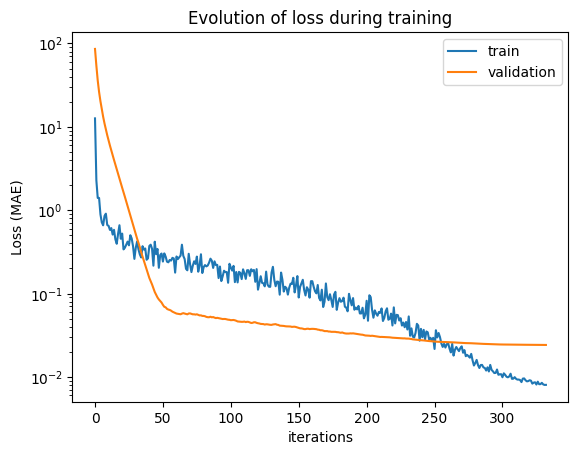

In [17]:
import matplotlib.pyplot as plt
#steps = [i for i in range(evaluation_interval, num_steps + 1, evaluation_interval)]
steps = range(len(train_loss))
plt.plot(steps, train_loss, label="train")
plt.plot(steps, val_loss, label="validation")
plt.title("Evolution of loss during training")
plt.xlabel("iterations")
plt.ylabel("Loss (MAE)")
plt.semilogy()
plt.legend()